In [1]:
from src.utils import (
    plot_stochastic_volatility_jump_path,
    generate_market_option_prices_across_time,
    append_market_iv,
    strip_state_df,
    plot_strategy_dashboard_plotly
)
from src.vol_arb import run_vol_arb_strategy

seed = 67
use_last_n = 60
exit_days_before_expiry = 10
kappa = 6.4
theta = 0.077
xi = 0.24
rho = -0.7
v0 = 0.042
muj = -0.165
sigmaj = 0.135
lambdaj = 1.62
noise_scale = 0.005

## True Price Path

In [2]:
# Execute the function
S_path, v_path, t_grid = plot_stochastic_volatility_jump_path(seed=seed, use_last_n=use_last_n)

## Market Option Prices

In [3]:
options_market_df = generate_market_option_prices_across_time(
    S_path=S_path,
    v_path=v_path,
    kappa_m=kappa,
    theta_m=theta,
    xi_m=xi,
    rho_m=rho,
    v0_m=v0,
    jump_intensity_m = lambdaj,
    jump_mean_m = muj,
    jump_std_m = sigmaj,
    r=0.02,
    dt=1/252,
    N=4096,
    alpha=1.5,
    eta=0.25,
    use_last_n=use_last_n,
    noise_scale=noise_scale,
)

print(f"Option data dimension: {options_market_df.shape}")
print("Unique option strikes:")
print(f"  {options_market_df['Strike'].unique().tolist()}")
options_market_df.head()

Option data dimension: (1680, 9)
Unique option strikes:
  [85.0, 87.0, 89.0, 91.0, 93.0, 95.0, 97.0, 99.0, 101.0, 103.0, 105.0, 107.0, 109.0, 111.0]


,t_index,S_t,v_t_market,Strike,Type,T,r,Market_Price,Contract
0,0,95.730665,0.079935,85.0,C,0.234127,0.02,14.082933,C_85_0
1,0,95.730665,0.079935,87.0,C,0.234127,0.02,12.497570,C_87_0
2,0,95.730665,0.079935,89.0,C,0.234127,0.02,11.108462,C_89_0
3,0,95.730665,0.079935,91.0,C,0.234127,0.02,9.706355,C_91_0
4,0,95.730665,0.079935,93.0,C,0.234127,0.02,8.494595,C_93_0


## Market Implied Volatility

In [4]:
options_market_df = append_market_iv(options_market_df)
print(f"Option data dimension: {options_market_df.shape}")
options_market_df.head()

Option data dimension: (1680, 10)


,t_index,S_t,v_t_market,Strike,Type,T,r,Market_Price,Contract,Market_IV
0,0,95.730665,0.079935,85.0,C,0.234127,0.02,14.082933,C_85_0,0.414345
1,0,95.730665,0.079935,87.0,C,0.234127,0.02,12.497570,C_87_0,0.398789
2,0,95.730665,0.079935,89.0,C,0.234127,0.02,11.108462,C_89_0,0.391983
3,0,95.730665,0.079935,91.0,C,0.234127,0.02,9.706355,C_91_0,0.379942
4,0,95.730665,0.079935,93.0,C,0.234127,0.02,8.494595,C_93_0,0.374438


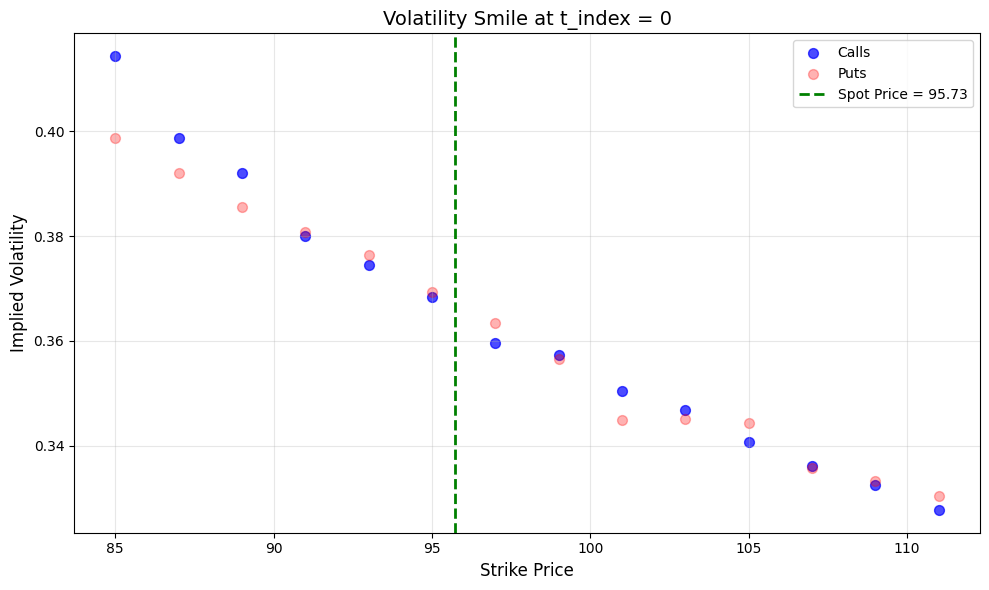

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your data is in a DataFrame called 'df'
# Filter for t_index = 0
df_t0 = options_market_df[options_market_df['t_index'] == 0].copy()

# Get the spot price (should be the same for all rows at t_index=0)
# Assuming the spot price column is called 'S_t' or 'spot_price'
# Adjust column name as needed
spot_price = df_t0['S_t'].iloc[0]  # or df_t0['spot_price'].iloc[0]

# Separate calls and puts
calls = df_t0[df_t0['Type'] == 'C']
puts = df_t0[df_t0['Type'] == 'P']

# Create the plot
plt.figure(figsize=(10, 6))

# Plot calls in blue
plt.scatter(calls['Strike'], calls['Market_IV'], 
            color='blue', label='Calls', alpha=0.7, s=50)

# Plot puts in red
plt.scatter(puts['Strike'], puts['Market_IV'], 
            color='red', label='Puts', alpha=0.3, s=50)

# Draw vertical line at spot price
plt.axvline(x=spot_price, color='green', linestyle='--', 
            linewidth=2, label=f'Spot Price = {spot_price:.2f}')

# Add labels and title
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Implied Volatility', fontsize=12)
plt.title('Volatility Smile at t_index = 0', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Optional: Add some styling
plt.tight_layout()

# Show the plot
plt.show()

## Volatility Arbitrage Strategy

In [6]:
state_df, initial_gross_exposure = run_vol_arb_strategy(
    options_market_df=options_market_df,
    calibration_N=1024,
    pricing_N=4096,
    alpha=1.5,
    eta=0.25,
    n_each_side=3,
    dt=1/252,
    exit_days_before_expiry=exit_days_before_expiry,
)
print(f"Initial Gross Exposure: {initial_gross_exposure:.4f}")

Initial Gross Exposure: 61.0566


## Diagnostics

In [7]:
state_df_reduced = strip_state_df(state_df)[:use_last_n-(exit_days_before_expiry+1)]
print(state_df_reduced.shape)
state_df_reduced.tail()

(49, 40)


,S_t,T,target_option_id,target_position,pnl_incremental,pnl_cumulative,mkt_iv_target,theo_iv_target,iv_diff_target,mkt_price_target,...,w_P_109,w_P_111,w_P_85,w_P_87,w_P_89,w_P_91,w_P_93,w_P_95,w_P_97,w_P_99
44,103.259441,0.059524,P_91,-1.0,-0.018434,0.067798,0.444015,0.374489,-0.069526,0.615650,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.000000,0.000000,0.000000,0.182699
45,102.195349,0.055556,P_91,-1.0,0.002522,0.070320,0.434321,0.345695,-0.088626,0.619339,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.000000,0.000000,0.208170,0.191723
46,100.939081,0.051587,P_91,-1.0,-0.011289,0.059031,0.424451,0.391517,-0.032934,0.651010,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.000000,0.177500,0.184969,0.169678
47,99.079624,0.047619,P_91,-1.0,0.043117,0.102148,0.400545,0.348081,-0.052464,0.711900,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.000000,0.265730,0.244499,0.176989
48,96.467735,0.043651,P_91,-1.0,0.076884,0.179032,0.366102,0.353199,-0.012903,0.900468,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.498672,0.393504,0.000000,0.000000


In [8]:
plot_strategy_dashboard_plotly(state_df_reduced, initial_gross_exposure)